Name - Bhushan Mandekar
Batch - 14

Mini Project: Dry Bean Type Classification

Objective
An agriculture company approaches you with a challenge: they are currently classifying different types of dry beans manually, a process that is labour-intensive, prone to errors and inefficient at scale. They want to automate this classification process using Artificial Intelligence to improve accuracy, reduce operational costs and ensure consistent quality in packaging and distribution.
As a data scientist, your role is to help them build a machine learning solution that can accurately classify bean types based on physical characteristics such as area, perimeter, shape and compactness. By doing this, you'll:
•	Automate the bean classification process using supervised learning techniques
•	Help the company reduce manual labour and cost
•	Improve the speed and reliability of quality control operations
•	Deliver a scalable solution for real-time classification in industrial settings
This project not only enhances your understanding of supervised machine learning but also demonstrates how AI can be directly applied to Agri-tech and food processing industries for tangible business impact.

________________________________________
Dataset
Use the attached data
 
________________________________________
Data Dictionary
All configurations (like area, shape and roundness) of data were gathered through camera-based systems using computer vision algorithms—a method commonly used in modern agricultural quality control setups.
Attribute Information:
1.	Area (A): The area of a bean zone and the number of pixels within its boundaries.
2.	Perimeter (P): Bean circumference is defined as the length of its border.
3.	Major axis length (L): The distance between the ends of the longest line that can be drawn from a bean.
4.	Minor axis length (l): The longest line that can be drawn from the bean while standing perpendicular to the main axis.
5.	Aspect ratio (K): Defines the relationship between L and l.
6.	Eccentricity (Ec): Eccentricity of the ellipse having the same moments as the region.
7.	Convex area (C): Number of pixels in the smallest convex polygon that can contain the area of a bean seed.
8.	Equivalent diameter (Ed): The diameter of a circle having the same area as a bean seed area.
9.	Extent (Ex): The ratio of the pixels in the bounding box to the bean area.
10.	Solidity (S): Also known as convexity. The ratio of the pixels in the convex shell to those found in beans.
11.	Roundness (R): Calculated with the following formula: (4piA)/(P^2)
12.	Compactness (CO): Measures the roundness of an object: Ed/L
13.	ShapeFactor1 (SF1)
14.	ShapeFactor2 (SF2)
15.	ShapeFactor3 (SF3)
16.	ShapeFactor4 (SF4)
17.	Class (Seker, Barbunya, Bombay, Cali, Dermosan, Horoz and Sira) 
________________________________________
Tasks
1. Import and Load the Data
•	Import necessary libraries (pandas, numpy, matplotlib, seaborn, sklearn etc.)
•	Load the dataset and explore it using .head(), .info(), and .describe()
________________________________________
2. Exploratory Data Analysis (EDA)
•	Visualize distributions of features using histograms and boxplots
•	Analyze the class distribution (check for class imbalance)
•	Plot feature correlations (eg heatmap)
•	Visualize multivariate relationships (pairplot)
•	Summarize key findings
________________________________________
3. Missing Values & Outlier Treatment
•	Check for and handle missing values
•	Detect and treat outliers if needed (Z-score / IQR methods/boxplots)
________________________________________
4. Feature Engineering & Preprocessing
•	Scale numerical features (StandardScaler / MinMaxScaler)
•	Encode categorical variables if necessary
•	Check and treat skewness if required
•	Split data into train/test sets (use stratified sampling while splitting)
________________________________________
5. Model Building: Try Multiple Classifiers
Train and test the dataset on a variety of supervised classification algorithms:
•	Logistic Regression
•	Decision Tree Classifier
•	Random Forest Classifier
•	K-Nearest Neighbors (KNN)
•	Support Vector Machine (SVM)
•	Ensemble Learning Methods
•	Naive Bayes and more…
Use Cross validation techniques to check if model performance is improved.
________________________________________
6. Handling Class Imbalance
•	Apply techniques like:
o	SMOTE (Synthetic Minority Over-sampling)
o	Random Oversampling / Undersampling
o	Class weighting
•	Evaluate if performance improves on minority classes
________________________________________
7. Model Evaluation & Overfitting Check
Use appropriate classification metrics:
•	Accuracy
•	Precision, Recall, and F1-Score (for each class)
•	Confusion Matrix

Check for Overfitting:
Compare training vs test accuracy and performance metrics.
________________________________________
8. Hyperparameter Tuning
•	Use GridSearchCV or RandomizedSearchCV to optimize parameters for top-performing models
•	Document the best parameters and performance improvement
________________________________________
9. Model Comparison Table
Model	Train Accuracy	Test Accuracy	F1 Score  	Overfitting (Y/N)
Logistic Regression				
Decision Tree				
Random Forest				
SVM				
KNN				
and other algos..				
Best Model				
________________________________________
10.  Build a Simple Classifier App
•	Use Streamlit to create a basic UI
•	Input physical measurements of a bean and get predicted class



In [1]:
# Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV
)

# Classification Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

# Metrics
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score
)

# Optional: Uncomment only if imbalanced-learn is installed
# from imblearn.over_sampling import SMOTE

In [2]:
%pip install openpyxl
import sys
!{sys.executable} -m pip install openpyxl

Note: you may need to restart the kernel to use updated packages.


In [3]:
import openpyxl
print(openpyxl.__version__)

3.1.5


Load Dataset

In [4]:
import pandas as pd

df = pd.read_excel("Dry_Beans_Dataset.xlsx")
print(df.head())
print(df.shape)

    Area  Perimeter  MajorAxisLength  MinorAxisLength  AspectRation  \
0  28395    610.291       208.178117       173.888747      1.197191   
1  28734    638.018       200.524796       182.734419      1.097356   
2  29380    624.110       212.826130       175.931143      1.209713   
3  30008    645.884       210.557999       182.516516      1.153638   
4  30140    620.134       201.847882       190.279279      1.060798   

   Eccentricity  ConvexArea  EquivDiameter    Extent  Solidity  roundness  \
0      0.549812       28715     190.141097  0.763923  0.988856   0.958027   
1      0.411785       29172     191.272750  0.783968  0.984986   0.887034   
2      0.562727       29690     193.410904  0.778113  0.989559   0.947849   
3      0.498616       30724     195.467062  0.782681  0.976696   0.903936   
4      0.333680       30417     195.896503  0.773098  0.990893   0.984877   

   Compactness  ShapeFactor1  ShapeFactor2  ShapeFactor3  ShapeFactor4  Class  
0     0.913358      0.007332  

In [5]:
import os

print("Current Working Directory:")
print(os.getcwd())

print("\nFiles Available:")
print(os.listdir())

Current Working Directory:
d:\AIML\Data_science\Deployment\B14

Files Available:
['.vscode', 'app.py', 'code.ipynb', 'Dry_Beans_Dataset.xlsx', 'medical Insurance cost prediction model', 'myenv', 'New folder', 'requirements.txt']


In [6]:
print(df.head())

print(df.info())

print(df.describe())

print(df.shape)

    Area  Perimeter  MajorAxisLength  MinorAxisLength  AspectRation  \
0  28395    610.291       208.178117       173.888747      1.197191   
1  28734    638.018       200.524796       182.734419      1.097356   
2  29380    624.110       212.826130       175.931143      1.209713   
3  30008    645.884       210.557999       182.516516      1.153638   
4  30140    620.134       201.847882       190.279279      1.060798   

   Eccentricity  ConvexArea  EquivDiameter    Extent  Solidity  roundness  \
0      0.549812       28715     190.141097  0.763923  0.988856   0.958027   
1      0.411785       29172     191.272750  0.783968  0.984986   0.887034   
2      0.562727       29690     193.410904  0.778113  0.989559   0.947849   
3      0.498616       30724     195.467062  0.782681  0.976696   0.903936   
4      0.333680       30417     195.896503  0.773098  0.990893   0.984877   

   Compactness  ShapeFactor1  ShapeFactor2  ShapeFactor3  ShapeFactor4  Class  
0     0.913358      0.007332  

Exploratory Data Analysis (EDA)
Check Class Distribution

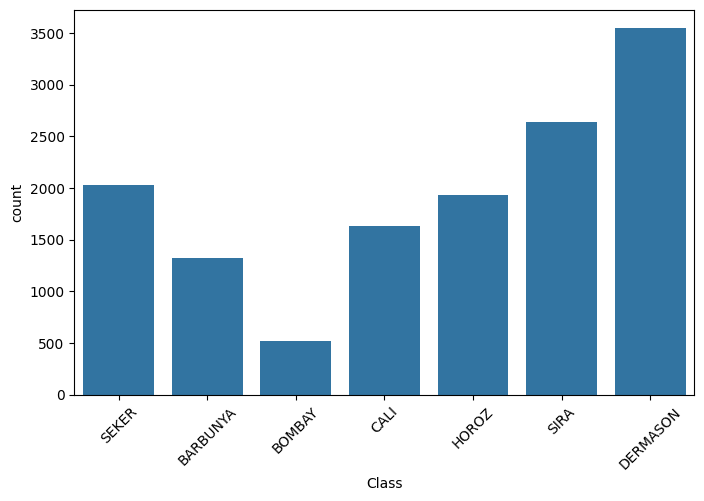

Class
DERMASON    3546
SIRA        2636
SEKER       2027
HOROZ       1928
CALI        1630
BARBUNYA    1322
BOMBAY       522
Name: count, dtype: int64


In [7]:
plt.figure(figsize=(8,5))
sns.countplot(x='Class', data=df)
plt.xticks(rotation=45)
plt.show()

print(df['Class'].value_counts())

Histogram

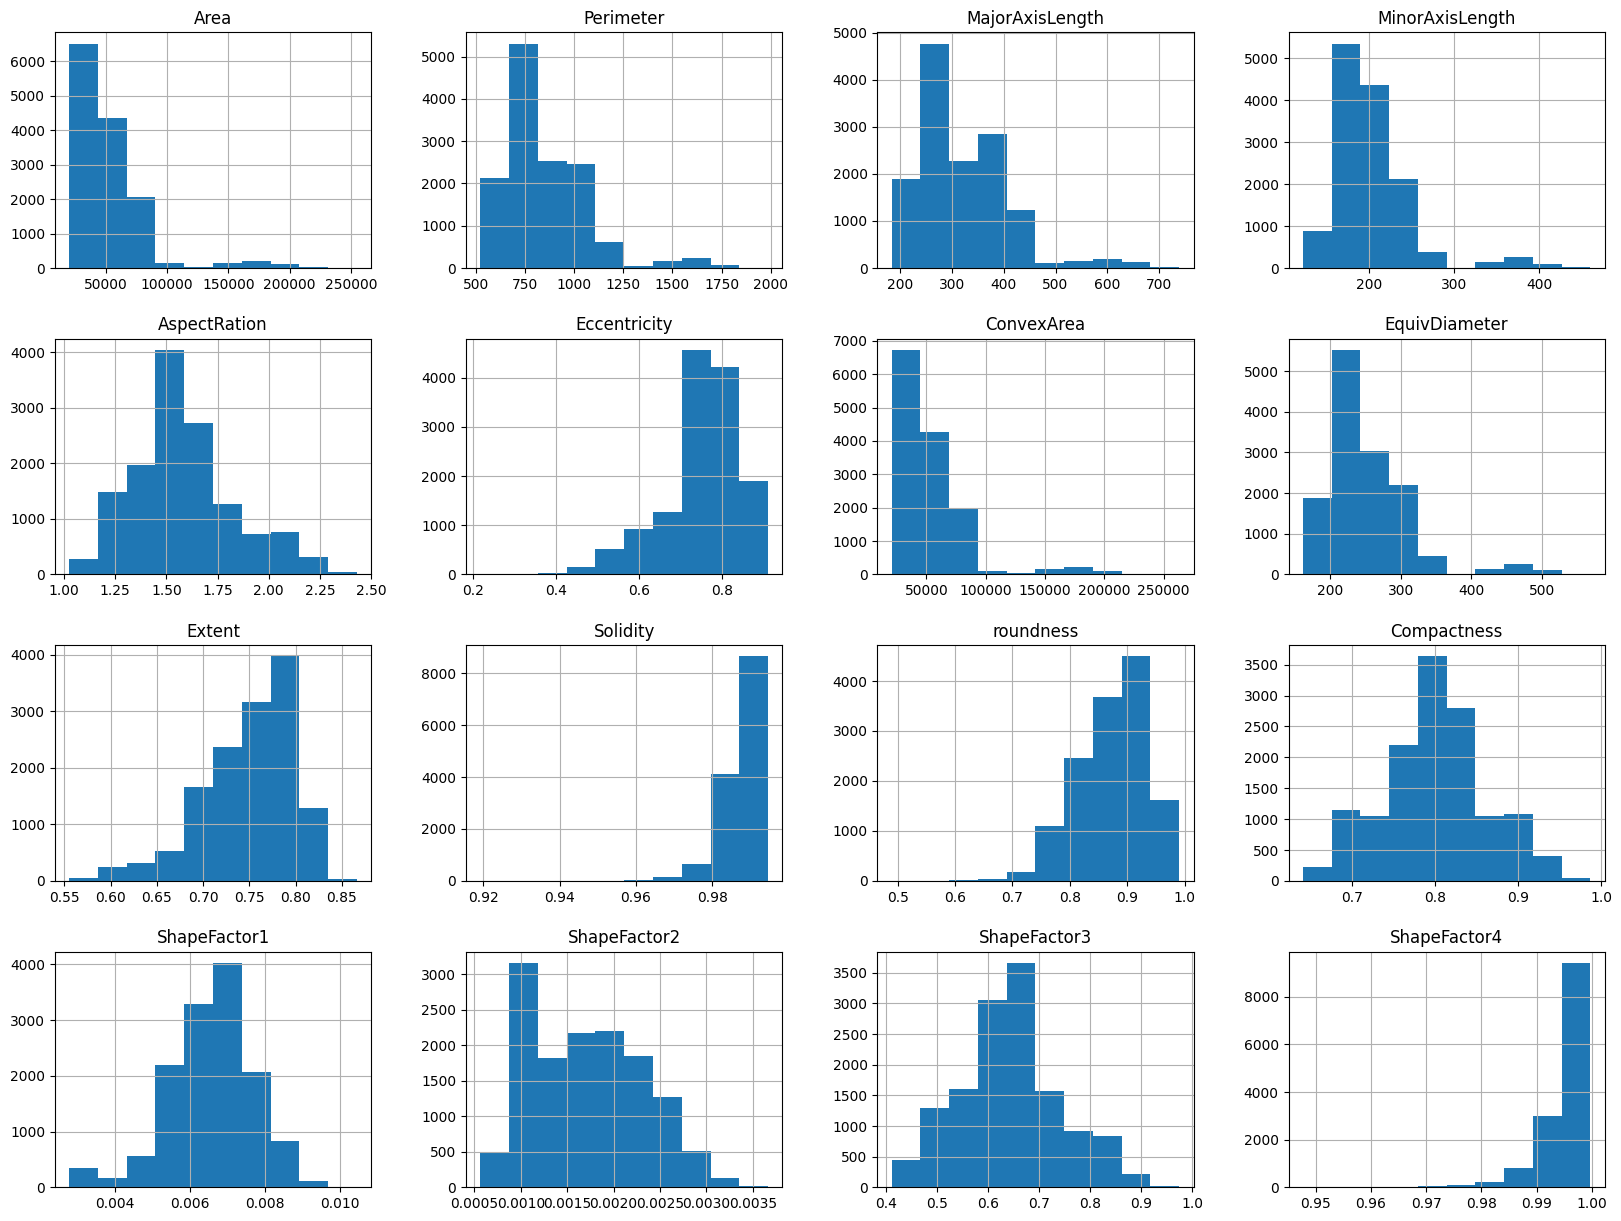

In [8]:
df.hist(figsize=(20,15))
plt.show()

Boxplots

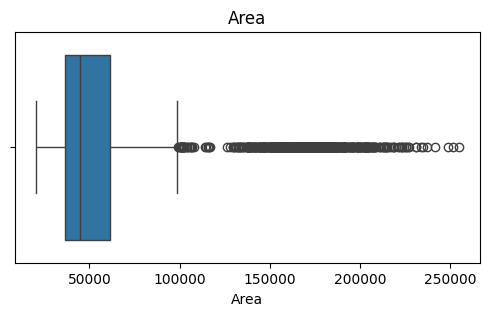

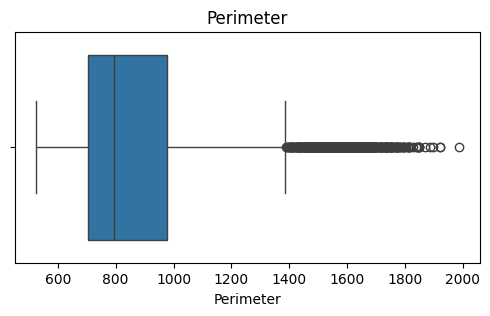

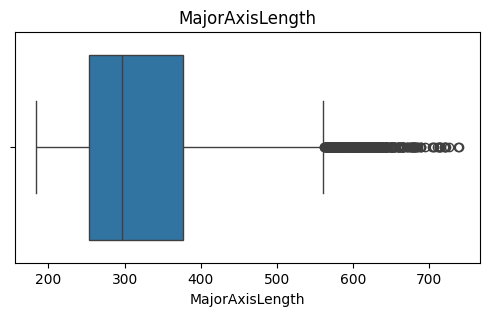

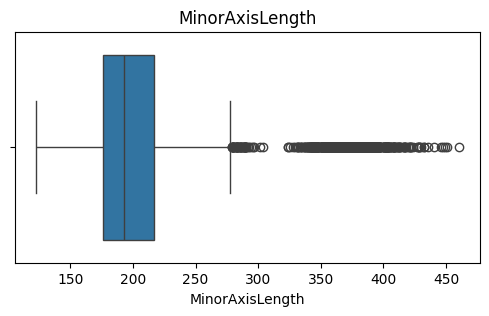

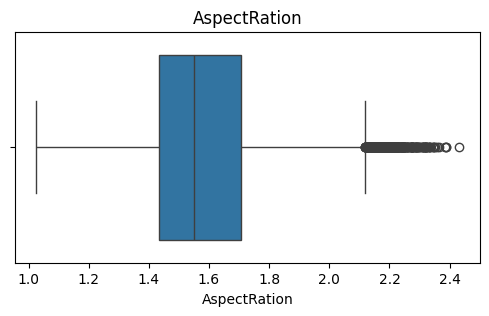

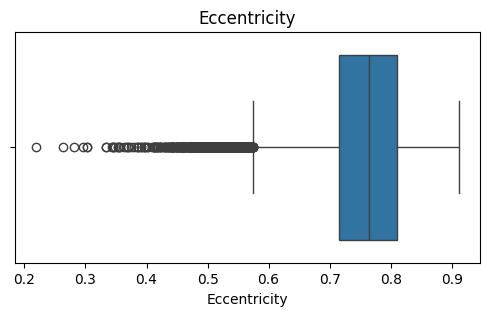

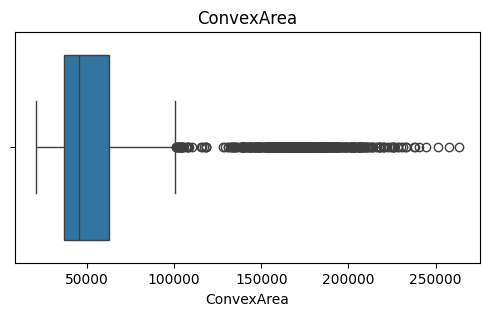

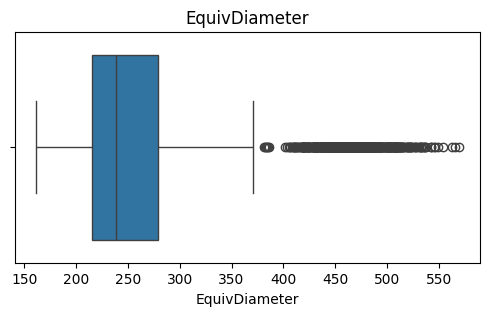

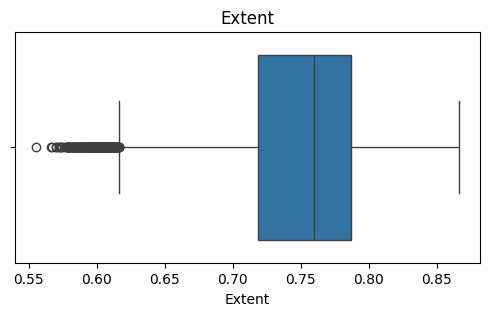

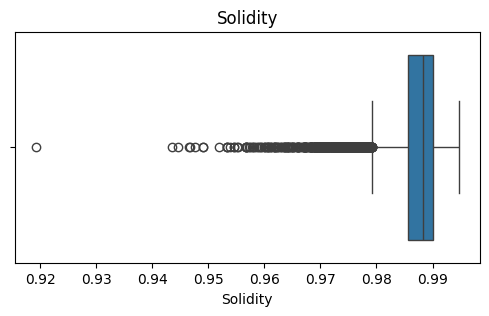

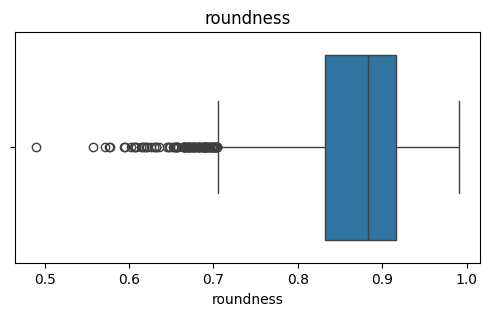

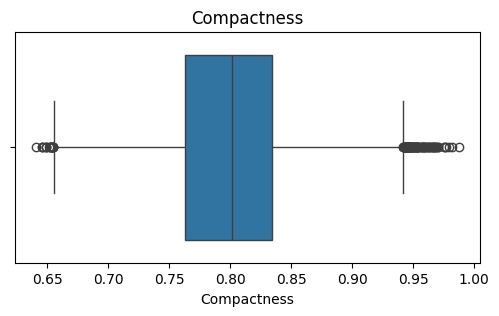

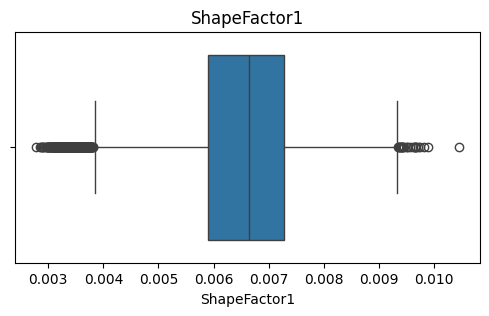

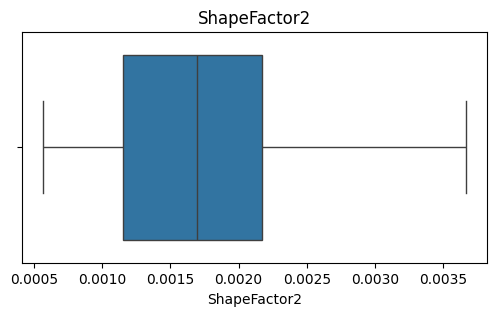

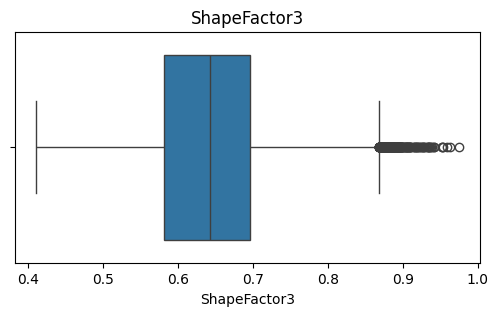

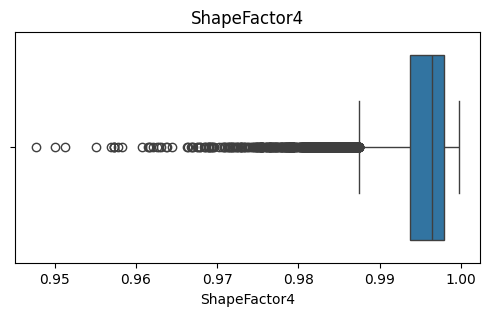

In [9]:
for col in df.columns[:-1]:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

Correlation Heatmap

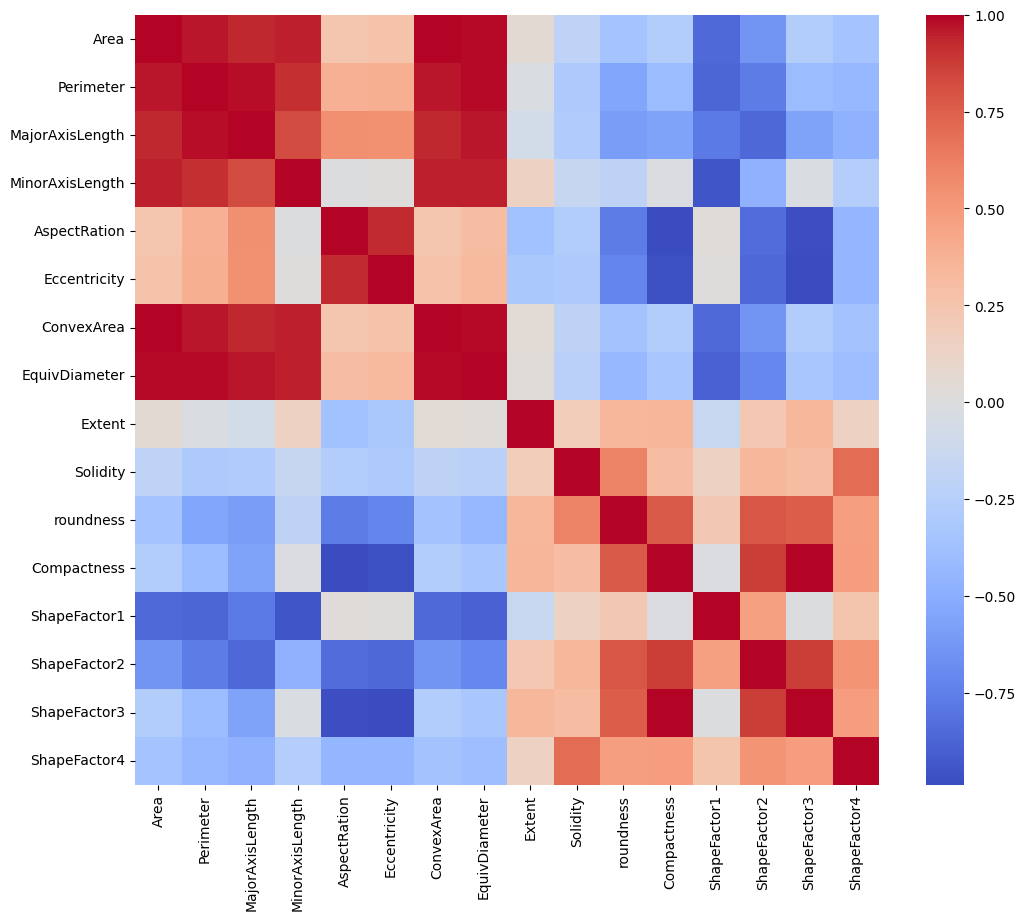

In [10]:
plt.figure(figsize=(12,10))
sns.heatmap(df.drop('Class', axis=1).corr(),
            cmap='coolwarm',
            annot=False)
plt.show()

Pairplot

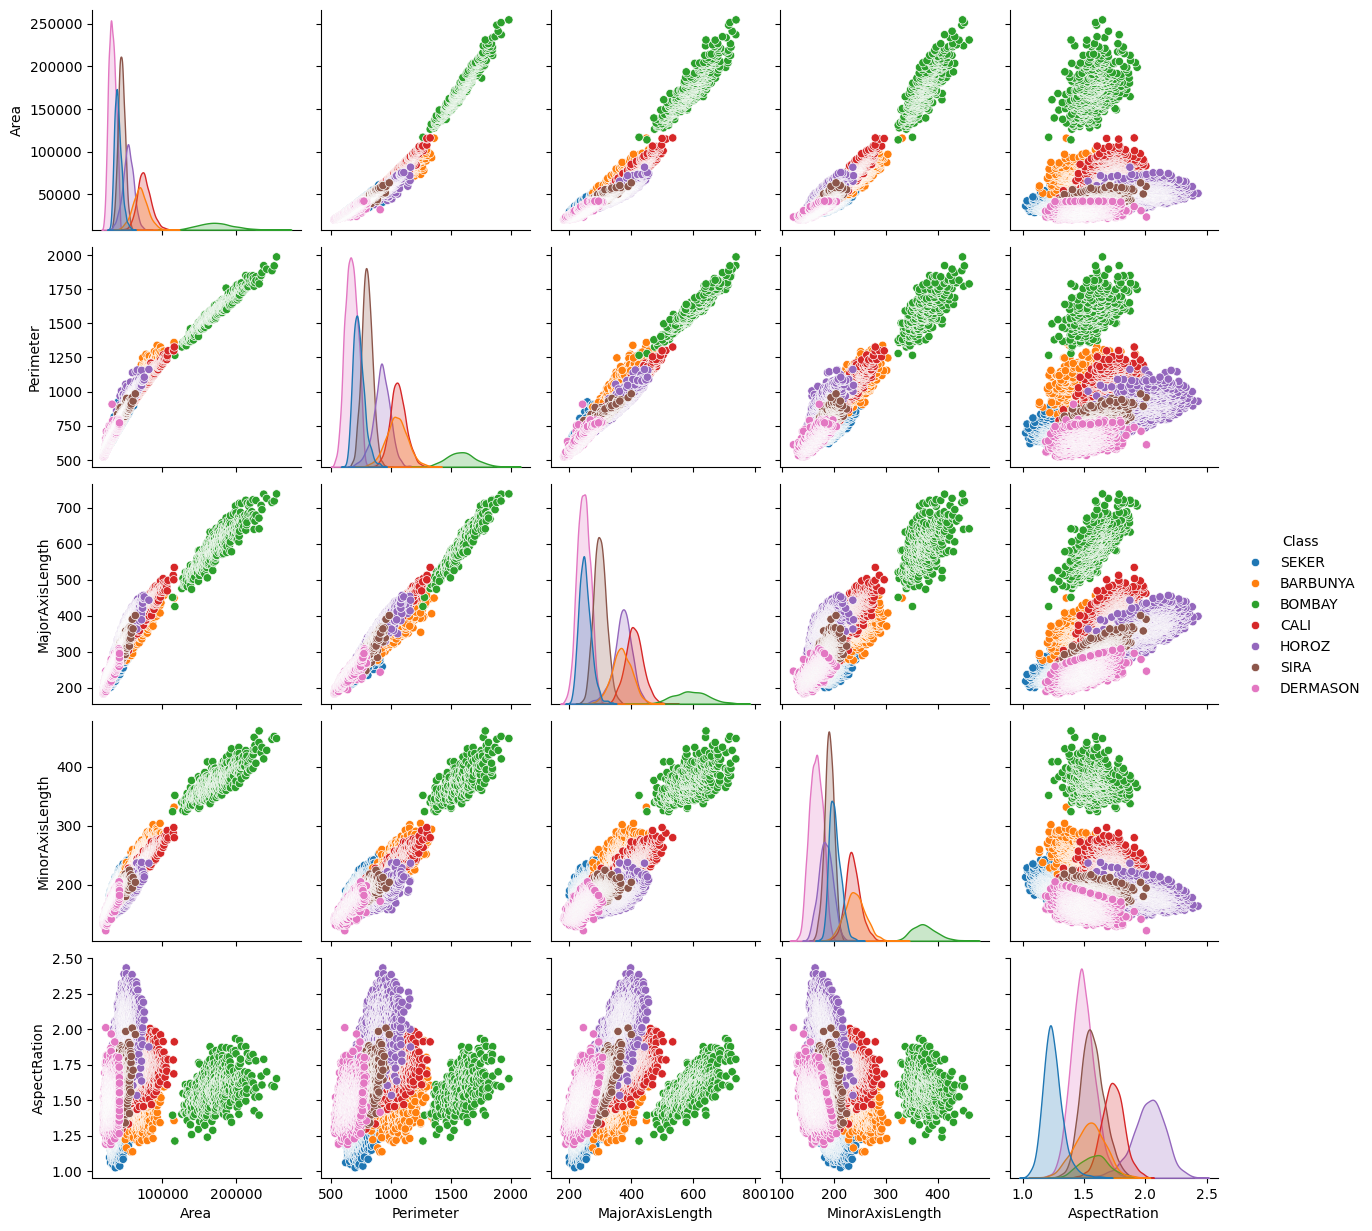

In [11]:
sns.pairplot(df,
             hue='Class',
             vars=df.columns[:5])
plt.show()

Missing Values & Outlier Treatment

Missing Values

In [12]:
print(df.isnull().sum())

Area               0
Perimeter          0
MajorAxisLength    0
MinorAxisLength    0
AspectRation       0
Eccentricity       0
ConvexArea         0
EquivDiameter      0
Extent             0
Solidity           0
roundness          0
Compactness        0
ShapeFactor1       0
ShapeFactor2       0
ShapeFactor3       0
ShapeFactor4       0
Class              0
dtype: int64


In [13]:
df.fillna(df.median(numeric_only=True), inplace=True)

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13606,42097,759.696,288.721612,185.944705,1.552728,0.765002,42508,231.515799,0.714574,0.990331,0.916603,0.801865,0.006858,0.001749,0.642988,0.998385,DERMASON
13607,42101,757.499,281.576392,190.713136,1.476439,0.735702,42494,231.526798,0.799943,0.990752,0.922015,0.822252,0.006688,0.001886,0.676099,0.998219,DERMASON
13608,42139,759.321,281.539928,191.187979,1.472582,0.734065,42569,231.631261,0.729932,0.989899,0.918424,0.822730,0.006681,0.001888,0.676884,0.996767,DERMASON
13609,42147,763.779,283.382636,190.275731,1.489326,0.741055,42667,231.653248,0.705389,0.987813,0.907906,0.817457,0.006724,0.001852,0.668237,0.995222,DERMASON


IQR Method for Outliers

In [14]:
numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR

    df[col] = np.where(df[col] > upper,
                       upper,
                       np.where(df[col] < lower,
                                lower,
                                df[col]))

Feature Engineering & Preprocessing
Features and Target

In [15]:
X = df.drop("Class", axis=1)
y = df["Class"]

Scaling

In [16]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

Train Test Split

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Handling Class Imbalance using SMOTE

In [18]:
from imblearn.over_sampling import SMOTE

In [19]:
import imblearn
print(imblearn.__version__)

0.14.2


In [20]:
from imblearn.over_sampling import SMOTE
print(SMOTE)

<class 'imblearn.over_sampling._smote.base.SMOTE'>


In [21]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print(y_train.value_counts())
print(y_train_smote.value_counts())

d:\AIML\Data_science\Deployment\B14\myenv\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "d:\AIML\Data_science\Deployment\B14\myenv\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "d:\AIML\Data_science\Deployment\B14\myenv\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "d:\AIML\Data_science\Deployment\B14\myenv\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs)

Class
DERMASON    2837
SIRA        2109
SEKER       1621
HOROZ       1542
CALI        1304
BARBUNYA    1057
BOMBAY       418
Name: count, dtype: int64
Class
SEKER       2837
HOROZ       2837
CALI        2837
SIRA        2837
DERMASON    2837
BARBUNYA    2837
BOMBAY      2837
Name: count, dtype: int64


In [22]:
import sys
print(sys.executable)

d:\AIML\Data_science\Deployment\B14\myenv\python.exe


Model Building

In [23]:
models = {

    "Logistic Regression":
    LogisticRegression(max_iter=2000),

    "Decision Tree":
    DecisionTreeClassifier(random_state=42),

    "Random Forest":
    RandomForestClassifier(random_state=42),

    "KNN":
    KNeighborsClassifier(),

    "SVM":
    SVC(),

    "Naive Bayes":
    GaussianNB(),

    "Extra Trees":
    ExtraTreesClassifier(random_state=42),

    "Gradient Boosting":
    GradientBoostingClassifier(random_state=42)
}

Train & Evaluate Models

In [24]:
results = []

for name, model in models.items():

    model.fit(X_train_smote, y_train_smote)

    train_pred = model.predict(X_train_smote)
    test_pred = model.predict(X_test)

    train_acc = accuracy_score(y_train_smote,
                               train_pred)

    test_acc = accuracy_score(y_test,
                              test_pred)

    f1 = f1_score(y_test,
                  test_pred,
                  average='weighted')

    results.append([
        name,
        train_acc,
        test_acc,
        f1
    ])

    print("\n",name)
    print(classification_report(
        y_test,
        test_pred
    ))


 Logistic Regression
              precision    recall  f1-score   support

    BARBUNYA       0.93      0.92      0.93       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.94      0.94      0.94       326
    DERMASON       0.94      0.88      0.91       709
       HOROZ       0.96      0.95      0.96       386
       SEKER       0.92      0.96      0.94       406
        SIRA       0.83      0.89      0.86       527

    accuracy                           0.92      2723
   macro avg       0.93      0.94      0.93      2723
weighted avg       0.92      0.92      0.92      2723


 Decision Tree
              precision    recall  f1-score   support

    BARBUNYA       0.90      0.88      0.89       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.89      0.90      0.90       326
    DERMASON       0.89      0.89      0.89       709
       HOROZ       0.93      0.92      0.93       386
       SEKER       0.92      0.95      0

Confusion Matrix

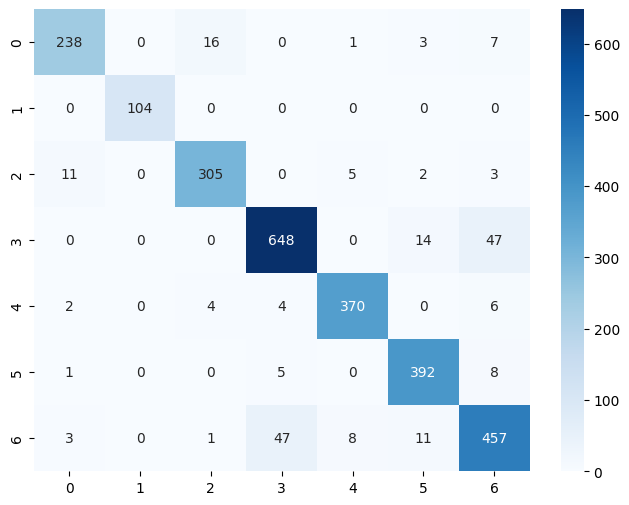

In [25]:
best_model = RandomForestClassifier()

best_model.fit(
    X_train_smote,
    y_train_smote
)

pred = best_model.predict(X_test)

cm = confusion_matrix(y_test,pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')
plt.show()

Cross Validation

In [26]:
rf = RandomForestClassifier()

scores = cross_val_score(
    rf,
    X_scaled,
    y,
    cv=5,
    scoring='accuracy'
)

print("CV Accuracy:",scores.mean())

CV Accuracy: 0.6071633509201153


Hyperparameter Tuning

Random Forest

In [27]:
param_grid = {

    'n_estimators':[100,200,300],

    'max_depth':[10,20,None],

    'min_samples_split':[2,5,10]
}

In [28]:
grid = GridSearchCV(

    RandomForestClassifier(
        random_state=42
    ),

    param_grid,

    cv=5,

    scoring='accuracy',

    n_jobs=-1
)

In [29]:
grid.fit(
    X_train_smote,
    y_train_smote
)

print(grid.best_params_)

print(grid.best_score_)

{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
0.9565442610994159


Best Model

In [30]:
best_rf = grid.best_estimator_

In [31]:
pred = best_rf.predict(X_test)

print(classification_report(
    y_test,
    pred
))

              precision    recall  f1-score   support

    BARBUNYA       0.92      0.89      0.91       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.94      0.93      0.93       326
    DERMASON       0.92      0.92      0.92       709
       HOROZ       0.96      0.96      0.96       386
       SEKER       0.94      0.97      0.95       406
        SIRA       0.87      0.86      0.86       527

    accuracy                           0.92      2723
   macro avg       0.93      0.93      0.93      2723
weighted avg       0.92      0.92      0.92      2723



Model Comparison Table

In [32]:
comparison = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Train Accuracy",
        "Test Accuracy",
        "F1 Score"
    ]
)

comparison["Overfitting"] = np.where(
    comparison["Train Accuracy"] -
    comparison["Test Accuracy"] > 0.05,
    "Yes",
    "No"
)

comparison.sort_values(
    by="Test Accuracy",
    ascending=False
)

,Model,Train Accuracy,Test Accuracy,F1 Score,Overfitting
4,SVM,0.948185,0.923614,0.923738,No
2,Random Forest,1.000000,0.921043,0.920881,Yes
7,Gradient Boosting,0.970240,0.921043,0.921044,No
0,Logistic Regression,0.941387,0.920308,0.920570,No
6,Extra Trees,1.000000,0.917738,0.917772,Yes
3,KNN,0.969233,0.912964,0.913026,Yes
5,Naive Bayes,0.911073,0.900110,0.900374,No
1,Decision Tree,1.000000,0.893133,0.892872,Yes


In [40]:
import joblib

# Save best model with compression
joblib.dump(
    best_rf,
    "best_model.joblib",
    compress=9
)

# Save scaler with compression
joblib.dump(
    scaler,
    "scaler.joblib",
    compress=9
)

print("Model and scaler saved successfully!")

Model and scaler saved successfully!
